# Attestation timings within committee - missed slots

#### Maria Silva, July 2025


## 1. Imports

In [71]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [72]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
data_path = "missed_slots_13169495_13219895"

In [73]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

#### Attestations

In [74]:
missed_atts_file = os.path.join(repo_dir, "data", data_path, "sample_atts.parquet")
atts_df = pd.read_parquet(missed_atts_file)
atts_df["atts_prop_time_ms"] = atts_df["atts_arrival_time_ms"]-4000
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4949565 entries, 0 to 4949564
Data columns (total 8 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   slot                  int64 
 1   node_name             object
 2   node_country          object
 3   atts_validator        int64 
 4   atts_subnet           object
 5   remote_peer_id        int64 
 6   atts_arrival_time_ms  int64 
 7   atts_prop_time_ms     int64 
dtypes: int64(5), object(3)
memory usage: 302.1+ MB


#### Validator info

In [75]:
val_file = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(val_file)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2073612 entries, 0 to 2073611
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.6+ MB


#### Client Versions

In [76]:
client_versions_file = os.path.join(repo_dir, "data", data_path, "client_versions.parquet")
client_versions_df = pd.read_parquet(client_versions_file)
client_versions_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6986961 entries, 0 to 6986960
Data columns (total 12 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   node_name                    object        
 1   node_country                 object        
 2   node_client_version          object        
 3   node_client_implementation   object        
 4   node_client_id               object        
 5   remote_agent_implementation  object        
 6   remote_agent_version         object        
 7   remote_agent_version_major   object        
 8   remote_agent_version_minor   object        
 9   remote_agent_version_patch   object        
 10  event_date_time              datetime64[ns]
 11  remote_peer_id               int64         
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 639.7+ MB


#### Join data and process

In [77]:
# Join
df = (
    atts_df.merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "unknown"})
)
# Group low cardinality entities into "other" category
entity_counts = df["entity"].value_counts()/len(df)
df = df.merge(entity_counts, left_on="entity", right_index=True)
df["entity"] = np.where(df["count"]>0.01, df["entity"], "other")
# Print info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4949565 entries, 0 to 4949564
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   slot                  int64  
 1   node_name             object 
 2   node_country          object 
 3   atts_validator        int64  
 4   atts_subnet           object 
 5   remote_peer_id        int64  
 6   atts_arrival_time_ms  int64  
 7   atts_prop_time_ms     int64  
 8   entity                object 
 9   count                 float64
dtypes: float64(1), int64(5), object(4)
memory usage: 377.6+ MB


In [78]:
df["slot"].nunique()

429

In [79]:
df["node_name"].sort_values().unique()

array(['ethpandaops/mainnet/xatu-tysm-ams3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-ams3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-blr1-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-sfo3-mainnet-005-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-003-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-004-subnets-0-1',
       'ethpandaops/mainnet/xatu-tysm-syd1-mainnet-005-subnets-0-1'],
      dtype=object)

In [80]:
# Join client versions with attestations data on remote_peer_id
# Check data sizes before merge to understand potential performance issues
print(f"Attestations data shape: {atts_df.shape}")
print(f"Client versions data shape: {client_versions_df.shape}")
print(f"Unique remote_peer_ids in attestations: {atts_df['remote_peer_id'].nunique()}")
print(f"Unique remote_peer_ids in client versions: {client_versions_df['remote_peer_id'].nunique()}")

# Use a more efficient merge approach - first check for common peer IDs
common_peer_ids = set(atts_df['remote_peer_id'].unique()) & set(client_versions_df['remote_peer_id'].unique())
print(f"Common peer IDs: {len(common_peer_ids)}")

# Filter client versions to only include relevant peer IDs to reduce merge size
relevant_client_versions = client_versions_df[
    client_versions_df['remote_peer_id'].isin(atts_df['remote_peer_id'].unique())
].copy()
print(f"Filtered client versions shape: {relevant_client_versions.shape}")


# df_with_clients = df.merge(
#     client_versions_df, 
#     left_on="remote_peer_id", 
#     right_on="remote_peer_id", 
#     how="left"
# )
# df_with_clients.info()


Attestations data shape: (4949565, 8)
Client versions data shape: (6986961, 12)
Unique remote_peer_ids in attestations: 2516
Unique remote_peer_ids in client versions: 26037
Common peer IDs: 2515
Filtered client versions shape: (1947542, 12)


## 3. Overall distribution

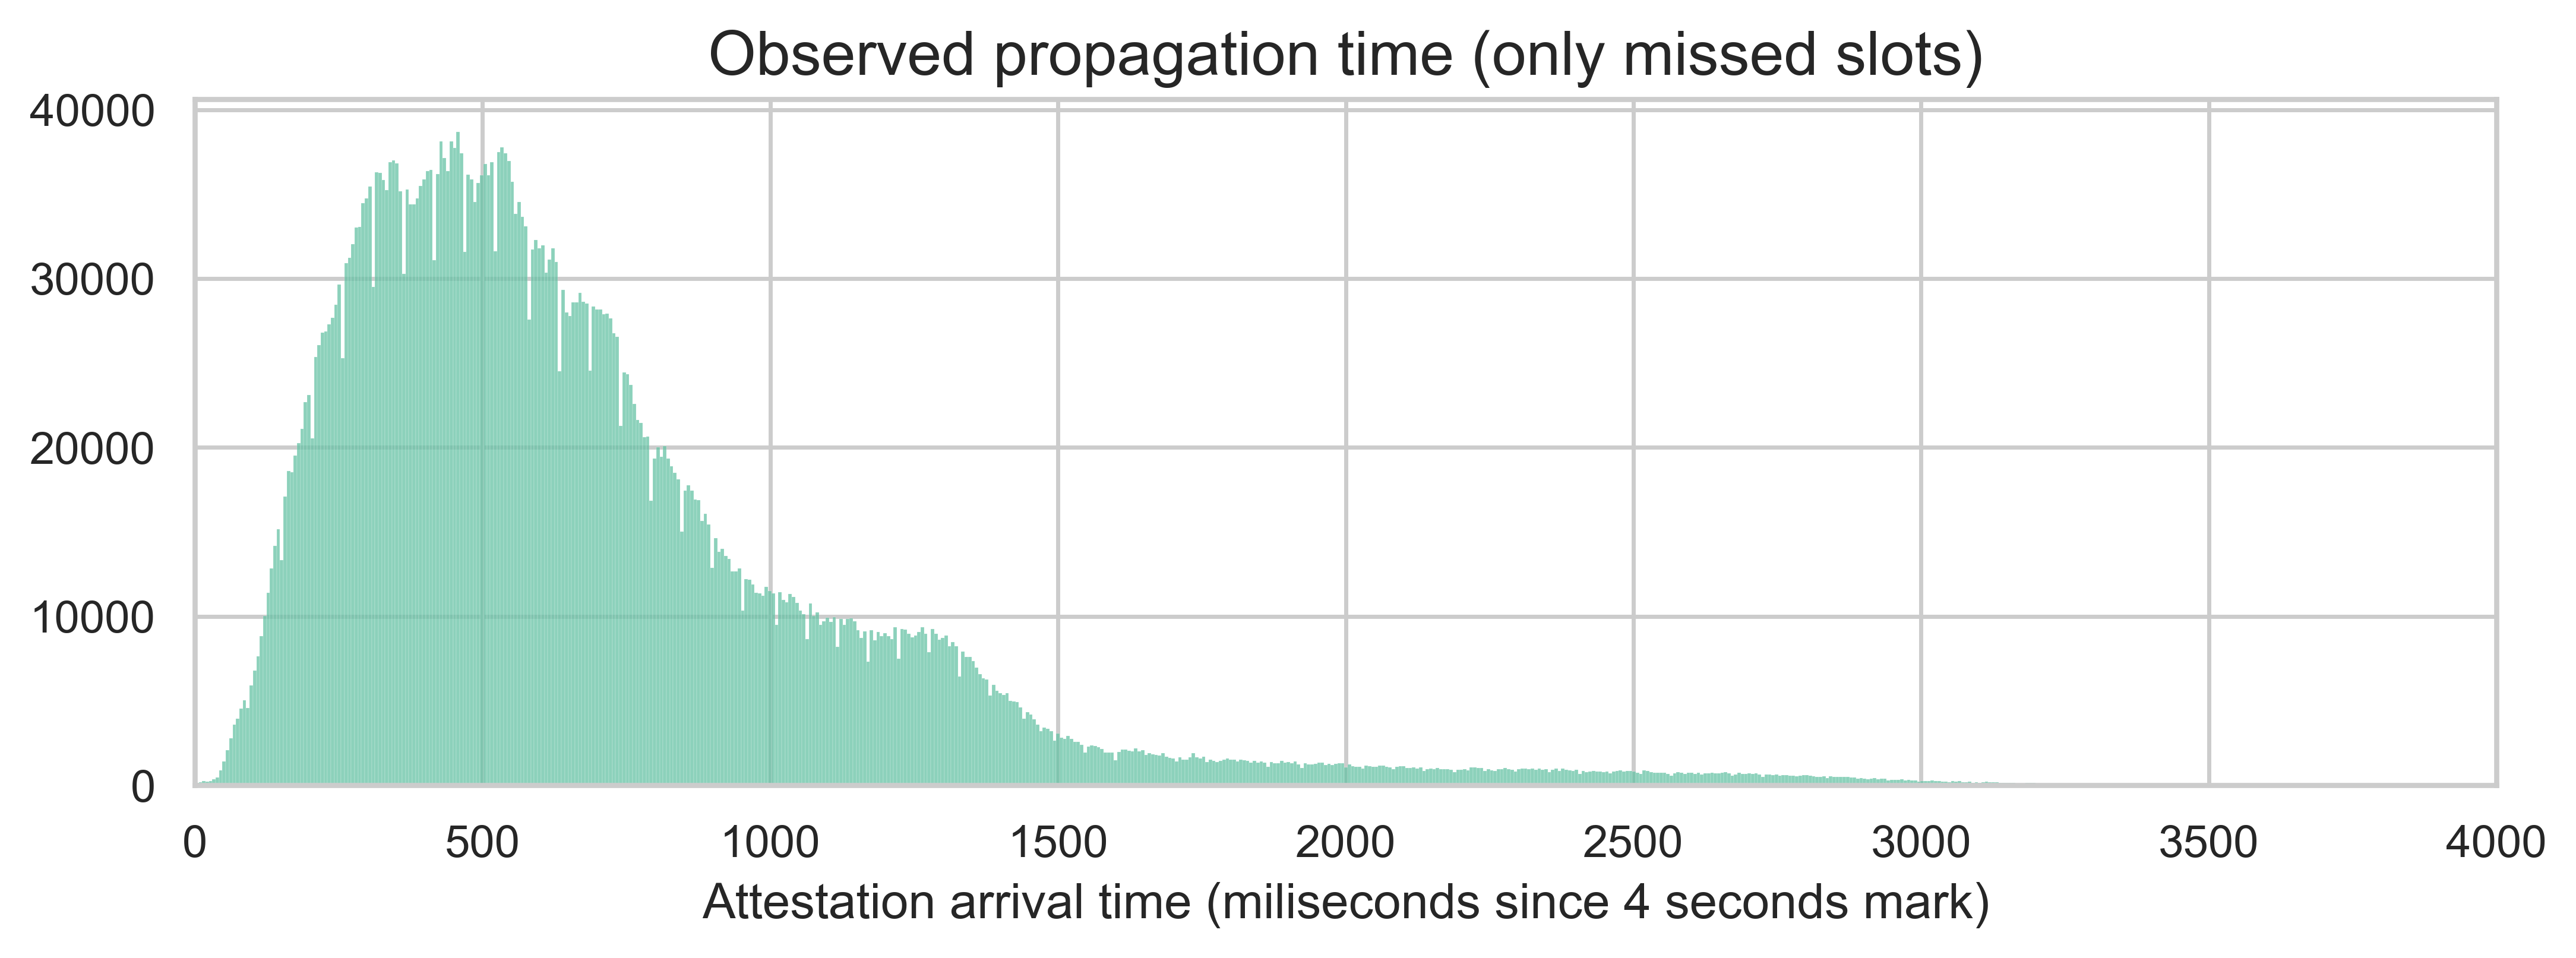

In [81]:
plt.figure(figsize=(10, 3))
sns.histplot(data=df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [82]:
df["atts_prop_time_ms"].agg(["mean", "std"])

mean    704.606729
std     501.197008
Name: atts_prop_time_ms, dtype: float64

In [84]:
df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     375.0
0.50     580.0
0.66     743.0
0.75     877.0
0.95    1612.0
0.99    2635.0
Name: atts_prop_time_ms, dtype: float64

#### Per beacon node

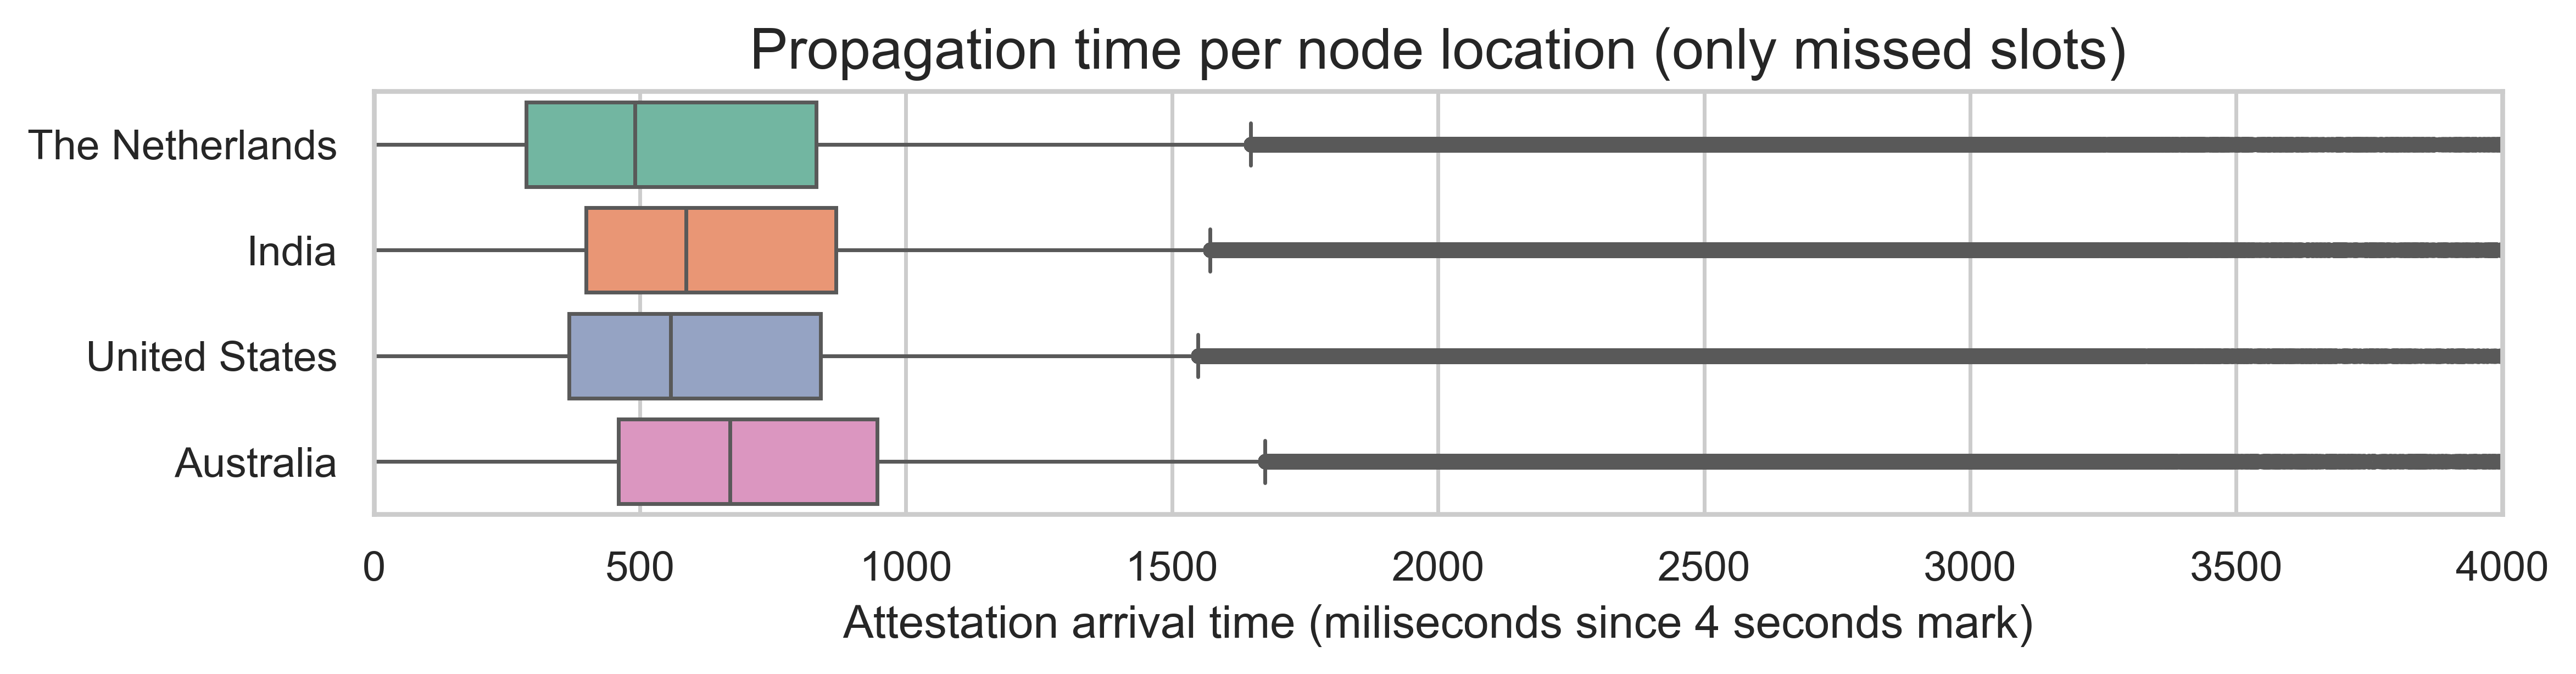

In [85]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=df.sort_values("node_name"),
    x="atts_prop_time_ms",
    y="node_country",
    hue="node_country",
    legend=False,
    fliersize=3
)
plt.xlim(0,4000)
plt.title("Propagation time per node location (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [87]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.66)

node_country
Australia          824.0
India              737.0
The Netherlands    674.0
United States      711.0
Name: atts_prop_time_ms, dtype: float64

In [88]:
df.groupby("node_country")["atts_prop_time_ms"].quantile(0.95)

node_country
Australia          1610.0
India              1604.0
The Netherlands    1622.0
United States      1607.0
Name: atts_prop_time_ms, dtype: float64

#### Per attester entity

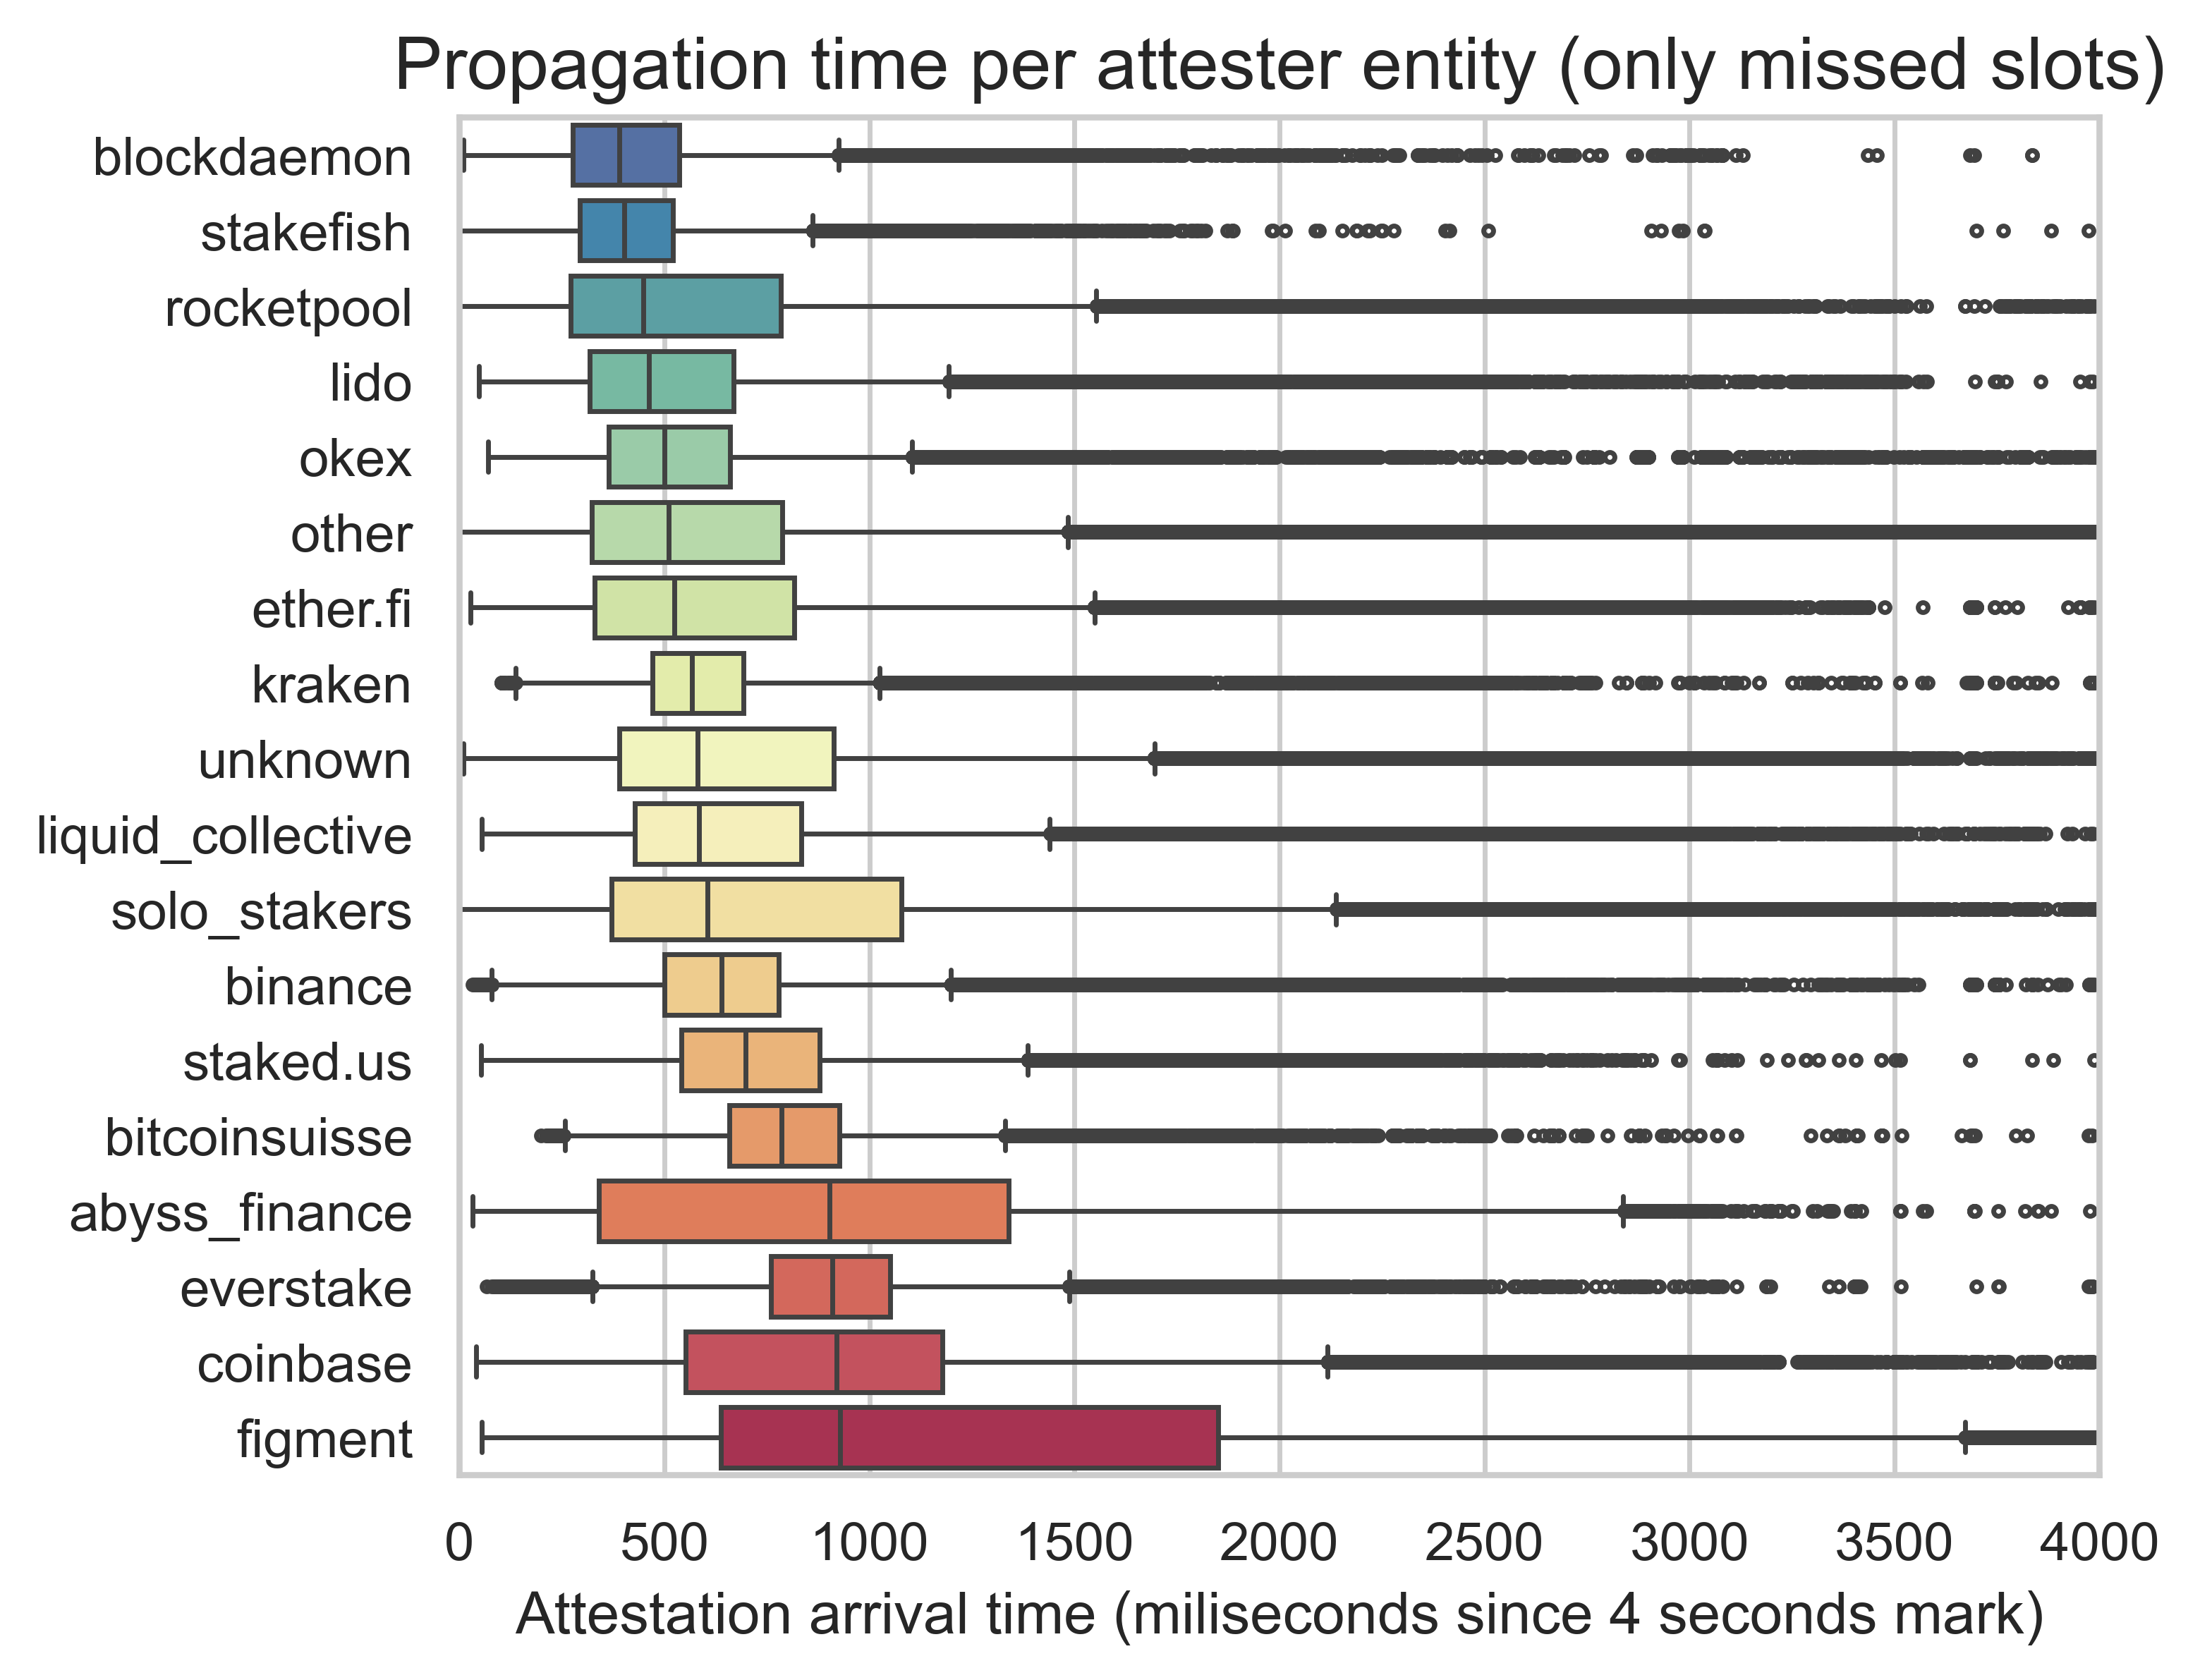

In [89]:
median_df = (
    df.groupby("entity")["atts_prop_time_ms"]
    .median()
    .reset_index()
    .rename(columns={"atts_prop_time_ms": "median"})
)
temp_df = df.merge(median_df, on="entity", how="left").sort_values("median")

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="entity",
    hue="entity",
    legend=False,
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0,4000)
plt.title("Propagation time per attester entity (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

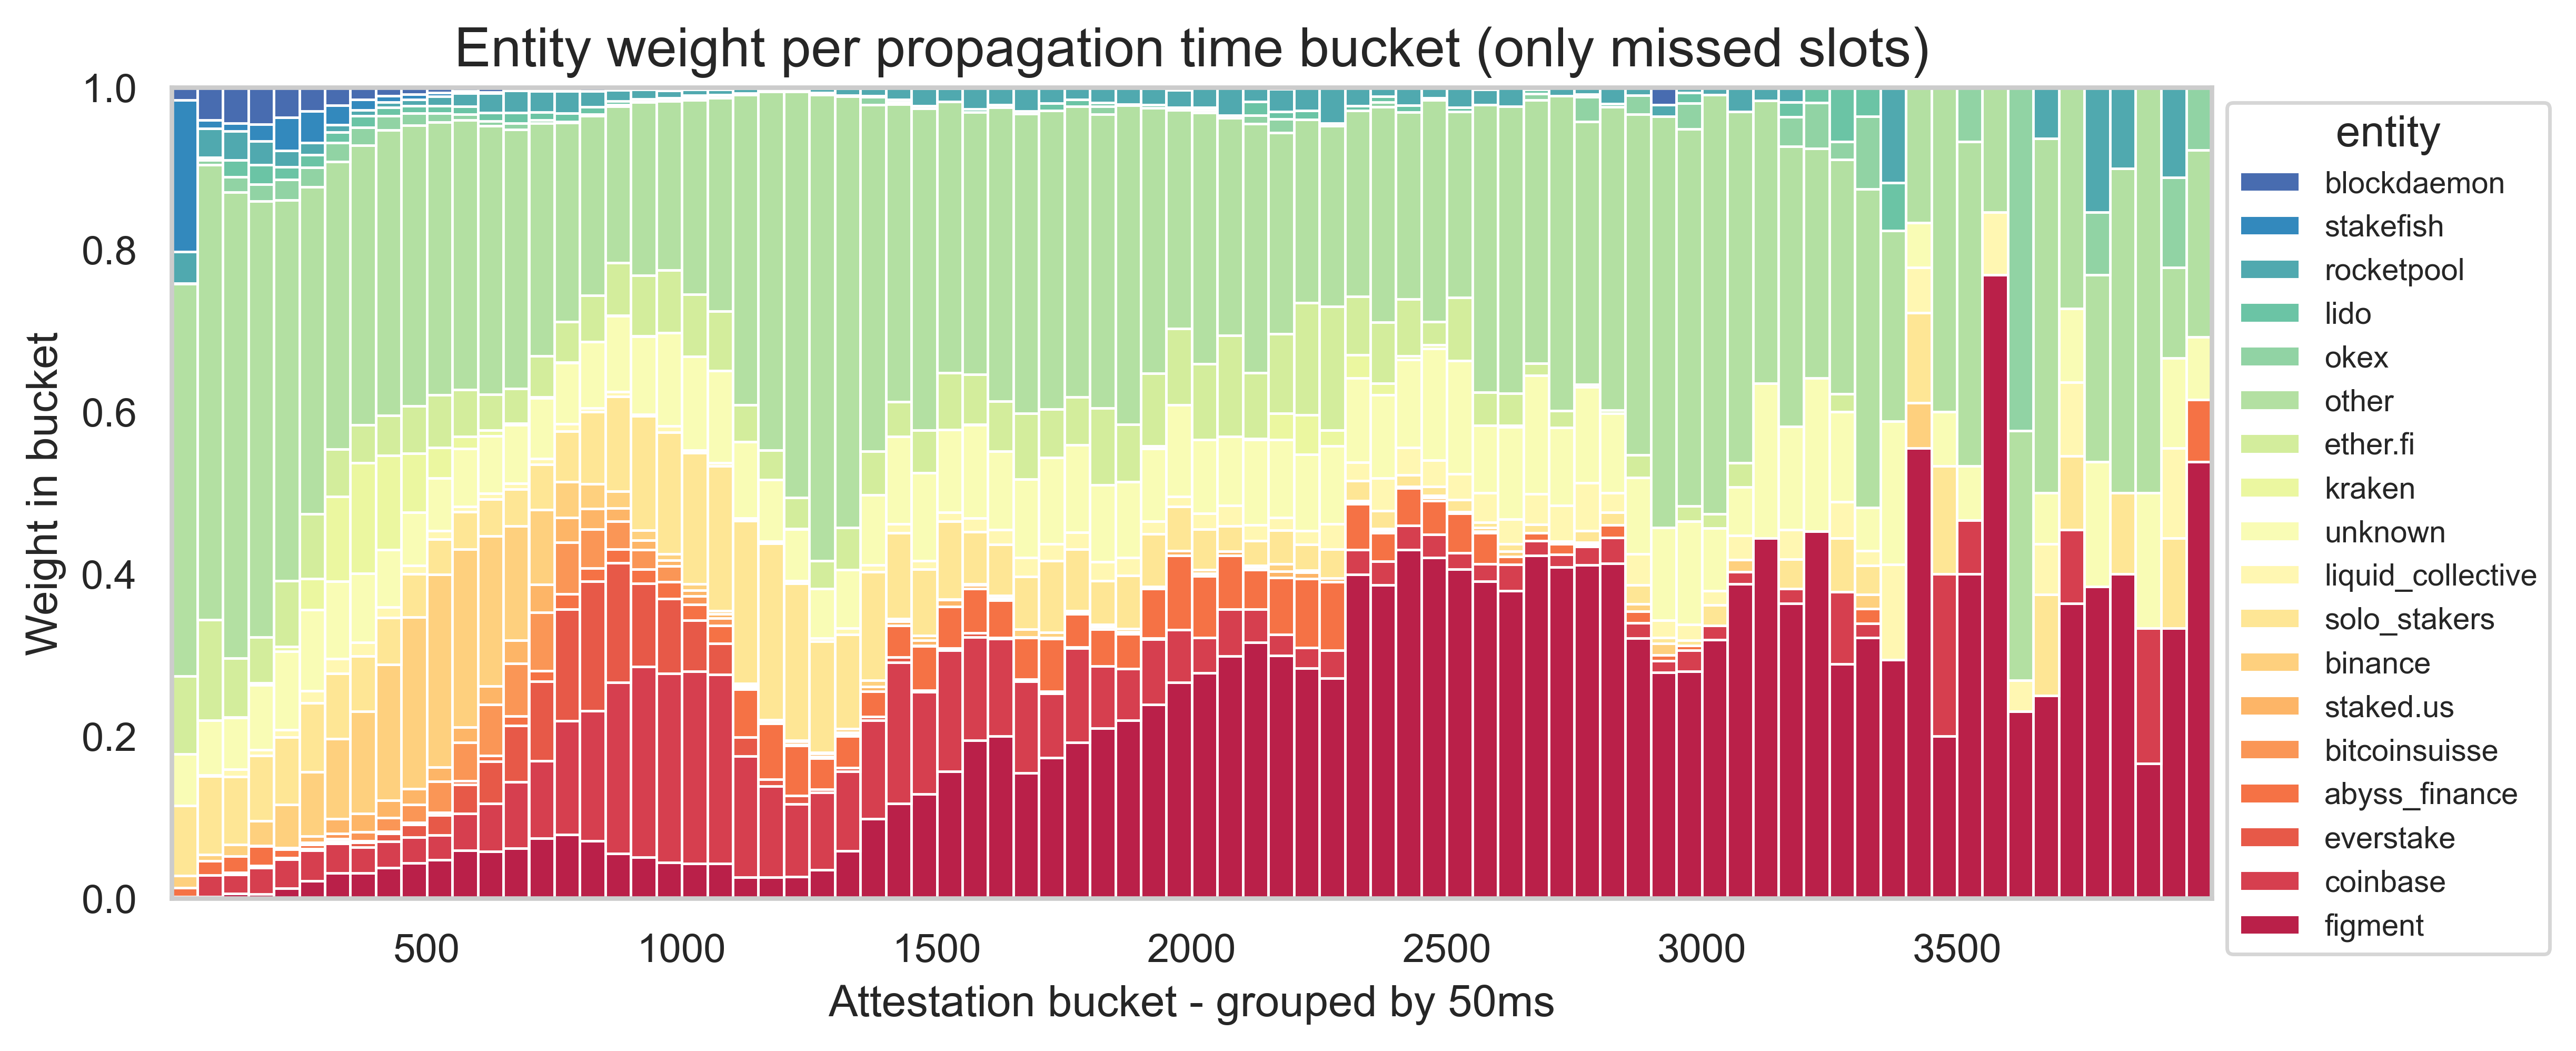

In [90]:
temp_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .merge(median_df, on="entity", how="left")
    .sort_values("median")
)
temp_df = temp_df[temp_df["atts_prop_time_ms"].between(0,4000)]
plt.figure(figsize=(10, 4))
ax = sns.histplot(
    data=temp_df,
    x="atts_prop_time_ms",
    hue="entity",
    multiple="fill",
    palette="Spectral_r",
    alpha=1,
    bins=80
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize='x-small')
plt.title("Entity weight per propagation time bucket (only missed slots)")
plt.ylabel("Weight in bucket")
plt.xlabel("Attestation bucket - grouped by 50ms")
plt.show()

#### Attestation Propgation by Client

Original client_versions_df shape: (6986961, 12)
Deduplicated shape: (26037, 4)
Merged df shape: (4949565, 11)

Attestation propagation statistics by client implementation:
  remote_agent_implementation    count        mean  median         std
3                      nimbus       82  503.134146   283.5  486.570050
0                      erigon        5  439.200000   511.0  248.825642
4                       prysm   214648  667.049658   546.0  470.806193
7                     unknown  4615712  704.870020   580.0  501.855771
1                  lighthouse    20701  783.586204   652.0  525.886786
5                        teku    26494  793.689062   658.0  506.880404
2                    lodestar     1701  719.281599   686.0  380.071175
6                        tysm    44849  805.951905   704.0  495.432705


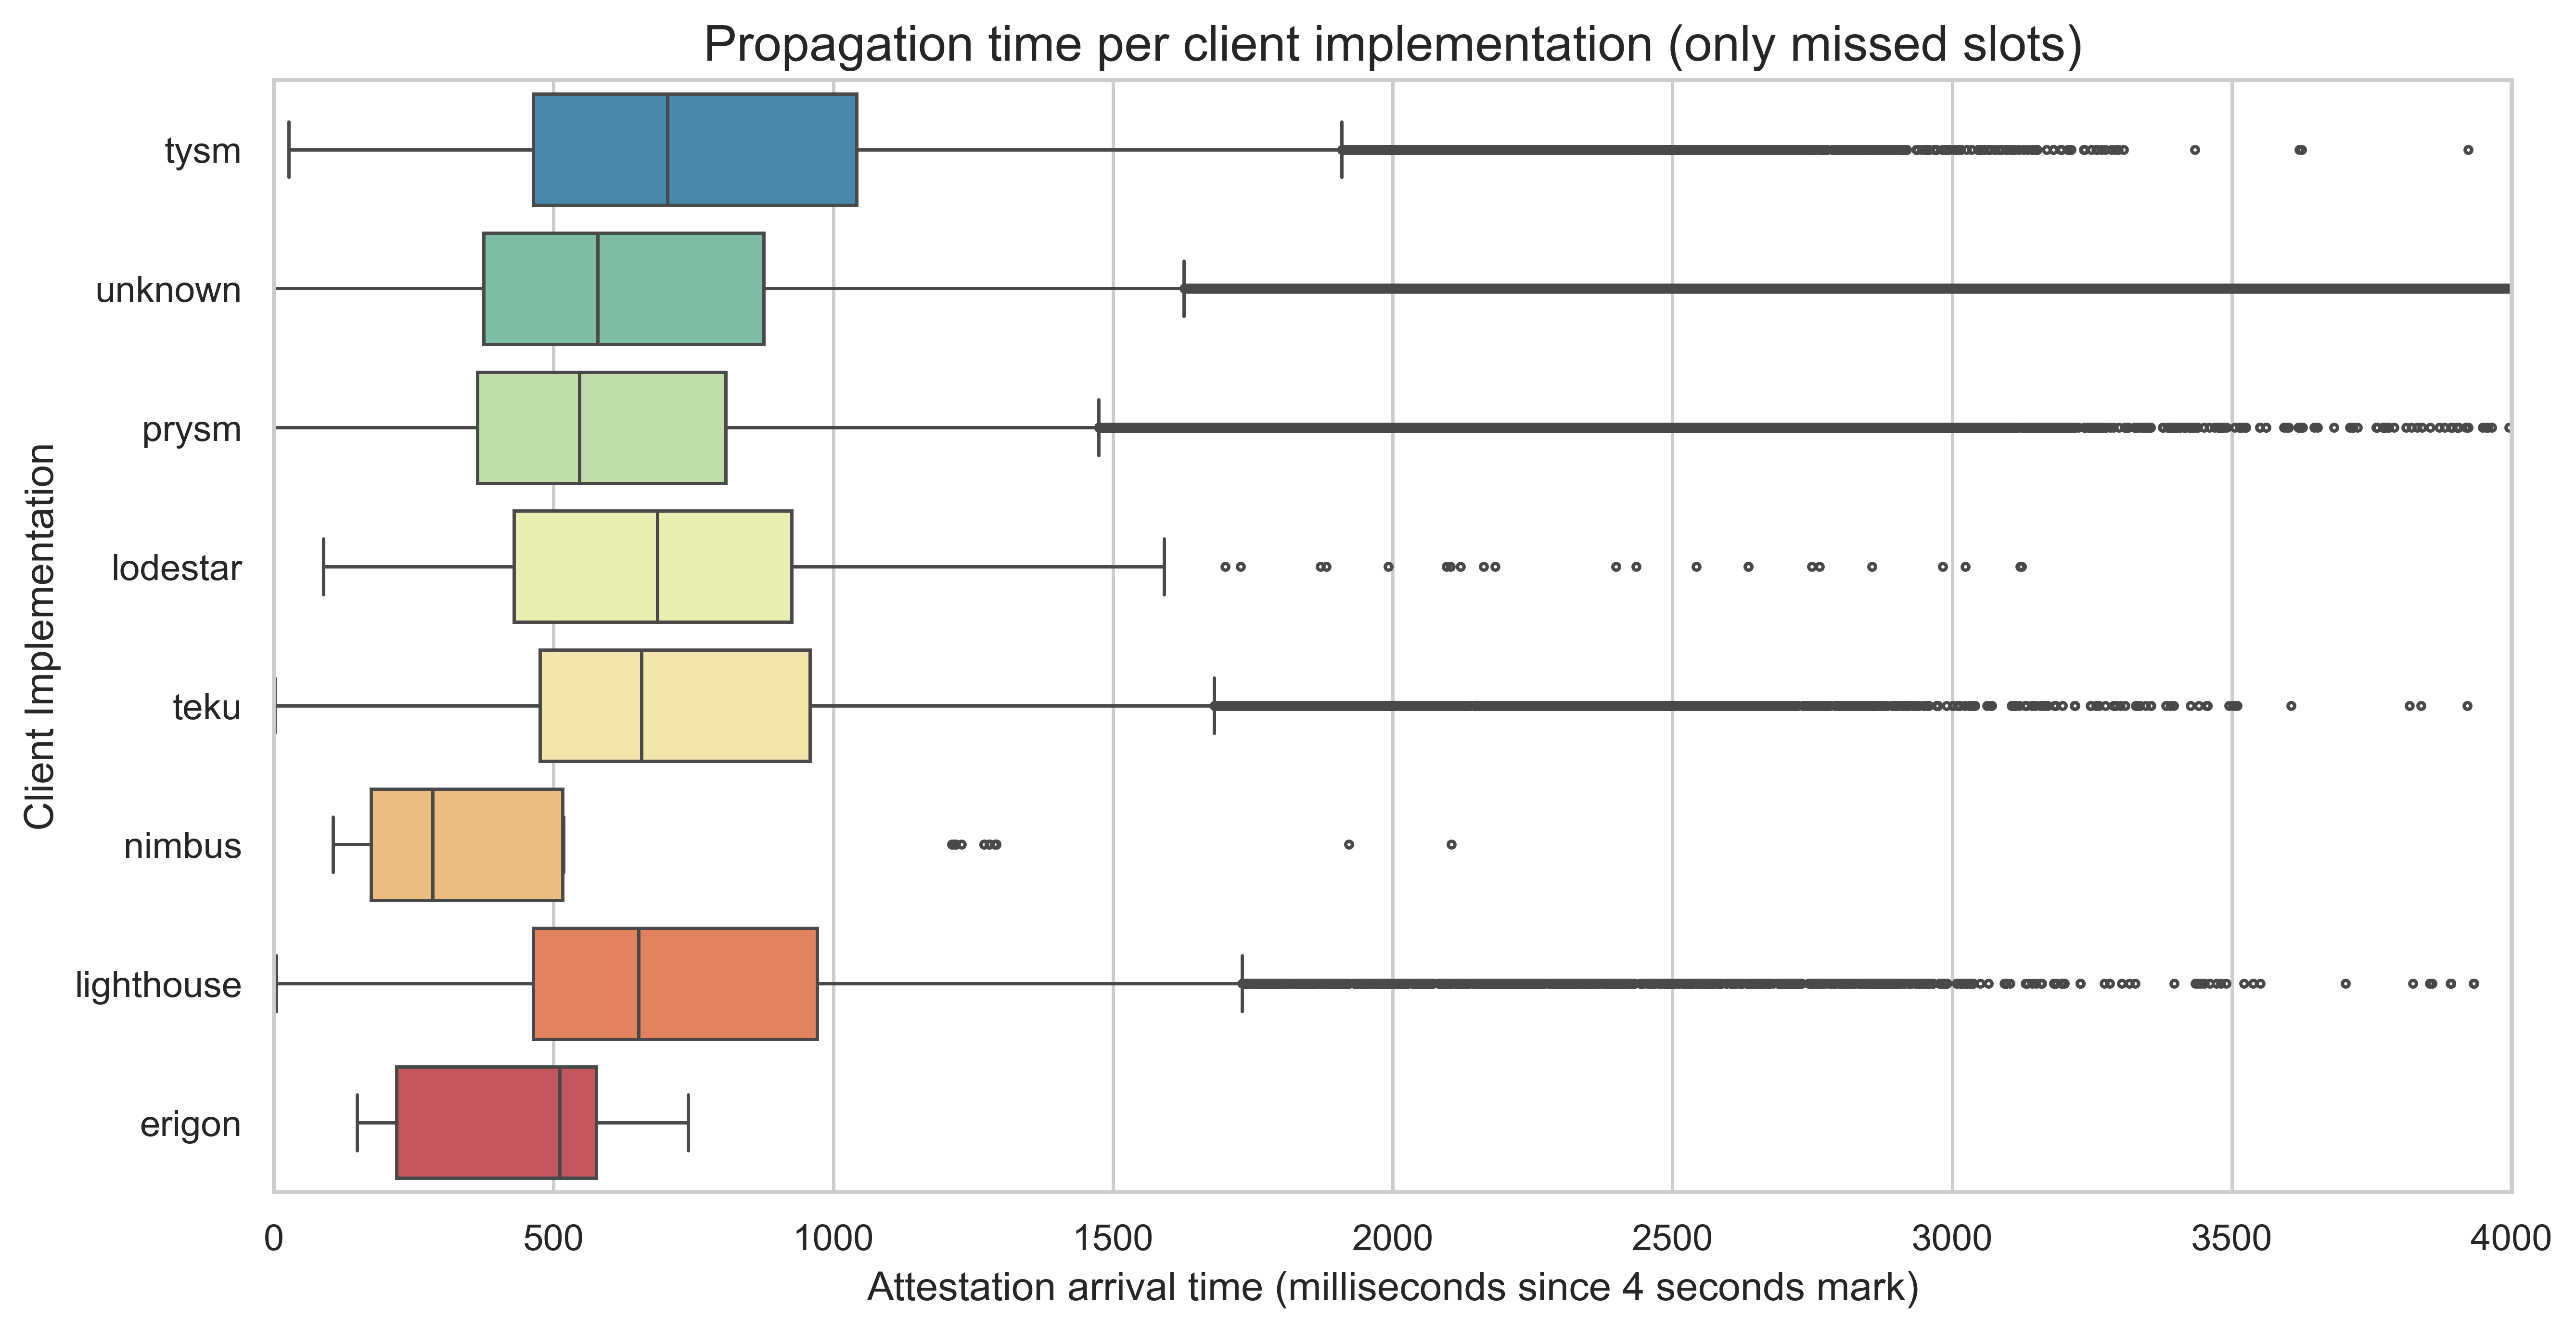


Percentiles by client implementation:
   remote_agent_implementation  Percentile  atts_prop_time_ms
0                       erigon        0.66             552.60
1                       erigon        0.95             708.00
2                   lighthouse        0.66             819.00
3                   lighthouse        0.95            1784.00
4                     lodestar        0.66             877.00
5                     lodestar        0.95            1298.00
6                       nimbus        0.66             351.74
7                       nimbus        0.95            1291.00
8                        prysm        0.66             694.00
9                        prysm        0.95            1487.00
10                        teku        0.66             817.00
11                        teku        0.95            1790.70
12                        tysm        0.66             886.00
13                        tysm        0.95            1760.00
14                     unknown 

In [91]:
# Map attestations to client versions using remote_peer_id
# IMPORTANT: client_versions_df has multiple rows per remote_peer_id (time series data)
# We need to deduplicate to ONE row per peer to avoid Cartesian product explosion

# Deduplicate: keep the most recent client version for each remote_peer_id
client_versions_dedup = (
    client_versions_df
    .sort_values('event_date_time', ascending=False)
    .drop_duplicates(subset=['remote_peer_id'], keep='first')
    [['remote_peer_id', 'remote_agent_implementation', 'remote_agent_version', 'remote_agent_version_major']]
)
print(f"Original client_versions_df shape: {client_versions_df.shape}")
print(f"Deduplicated shape: {client_versions_dedup.shape}")

# Now merge - this will be fast since we have 1:1 mapping on remote_peer_id
df_with_client = atts_df.merge(client_versions_dedup, on='remote_peer_id', how='left')
print(f"Merged df shape: {df_with_client.shape}")

# Group by client implementation and calculate statistics
client_stats = (
    df_with_client[df_with_client["atts_prop_time_ms"] > 0]
    .groupby("remote_agent_implementation")["atts_prop_time_ms"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .sort_values("median")
)

print("\nAttestation propagation statistics by client implementation:")
print(client_stats)

# Create visualization of propagation times by client implementation
temp_df = df_with_client[df_with_client["atts_prop_time_ms"].between(0, 4000)]
temp_df = temp_df.dropna(subset=['remote_agent_implementation'])

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="remote_agent_implementation",
    palette="Spectral_r",
    fliersize=2
)
plt.xlim(0, 4000)
plt.title("Propagation time per client implementation (only missed slots)")
plt.ylabel("Client Implementation")
plt.xlabel("Attestation arrival time (milliseconds since 4 seconds mark)")
plt.show()

# Show percentiles by client implementation
client_percentiles = (
    df_with_client[df_with_client["atts_prop_time_ms"] > 0]
    .groupby("remote_agent_implementation")["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_1": "Percentile"})
)
print("\nPercentiles by client implementation:")
print(client_percentiles)


#### Min across nodes

In [92]:
min_df = df.groupby(["slot", "atts_validator"])["atts_prop_time_ms"].min().reset_index()

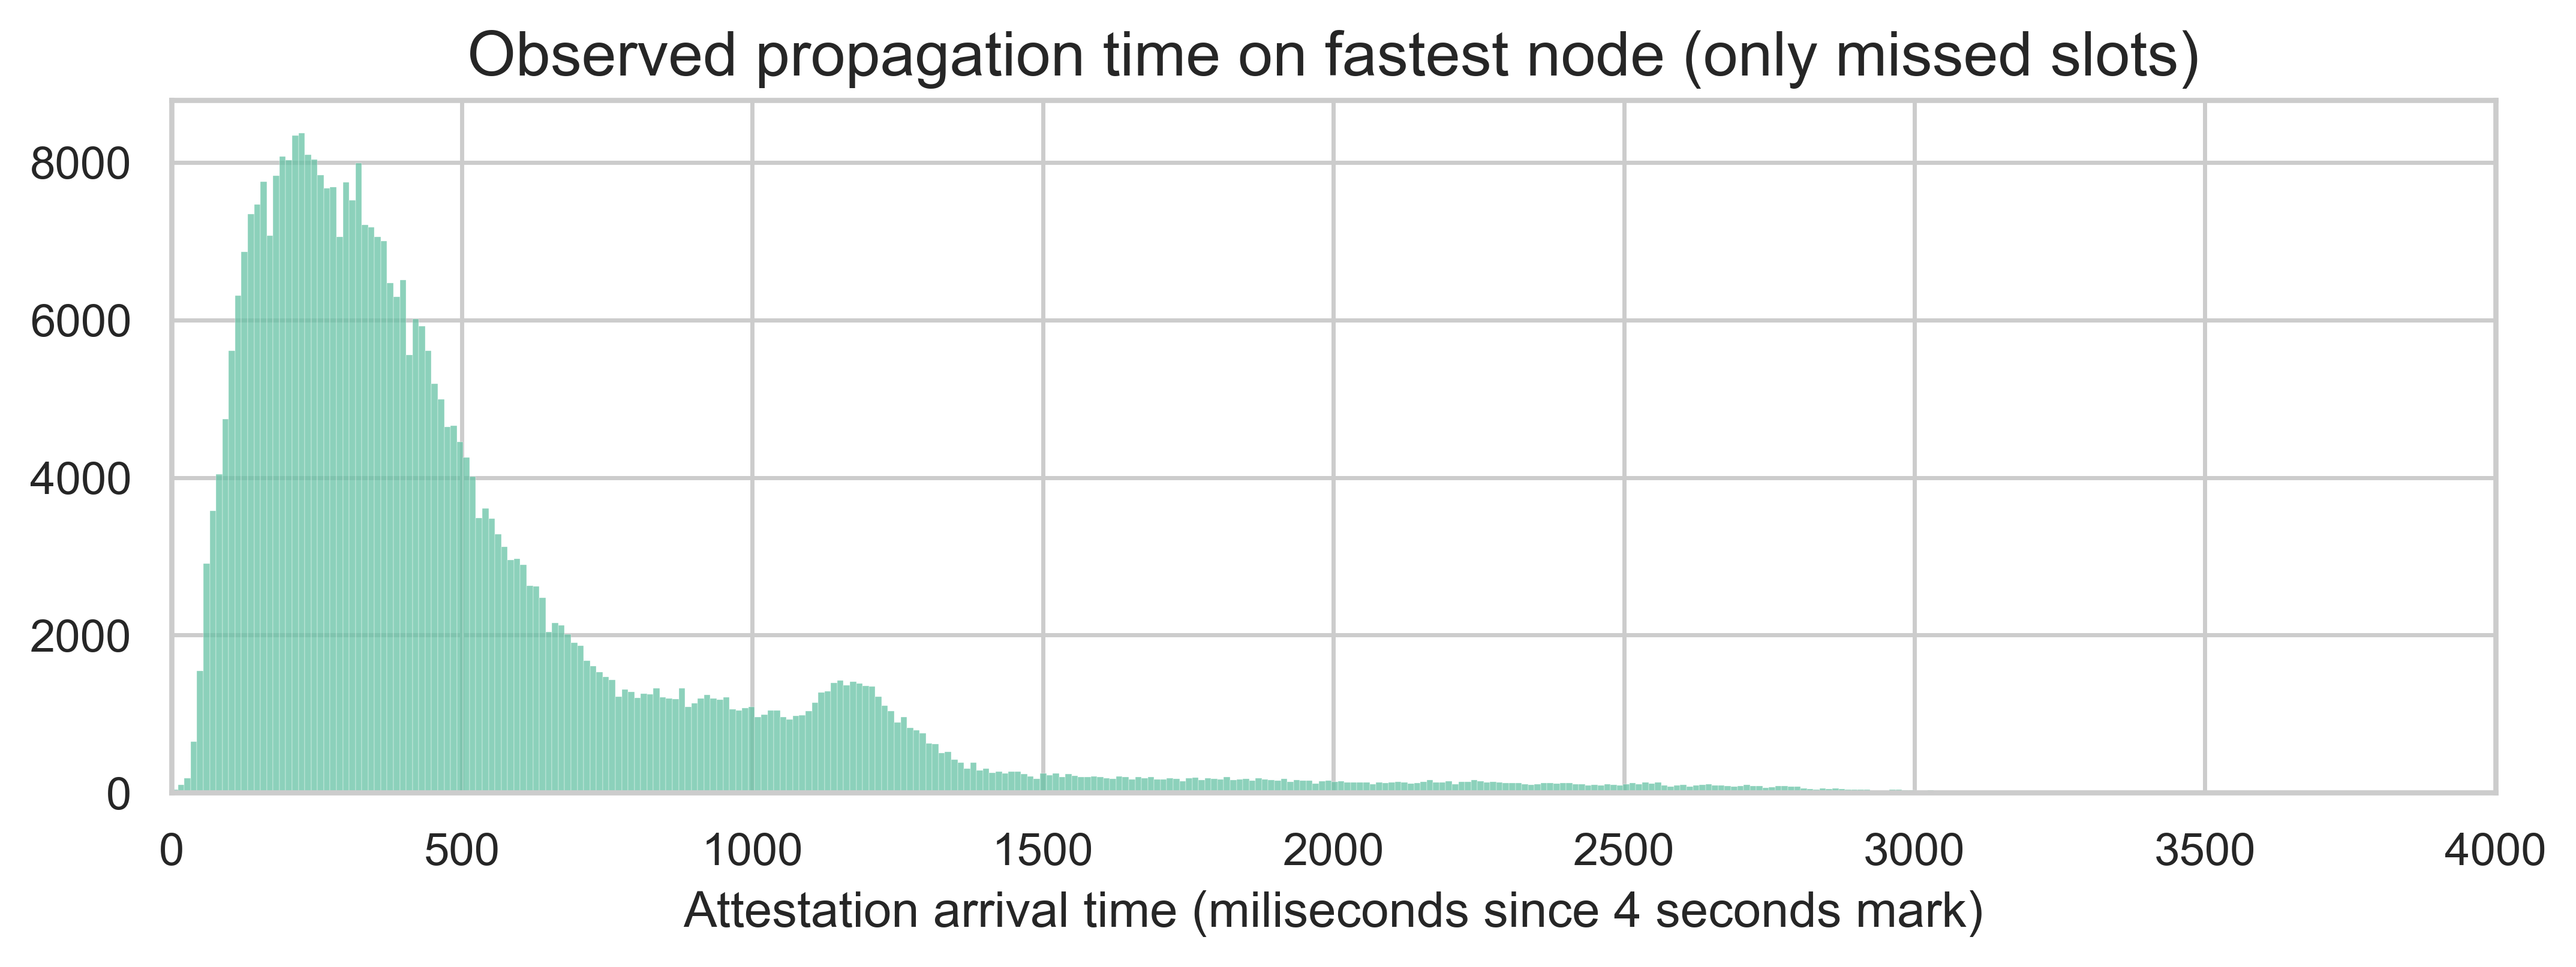

In [93]:
plt.figure(figsize=(10, 3))
sns.histplot(data=min_df, x="atts_prop_time_ms")
plt.xlim(0, 4000)
plt.title("Observed propagation time on fastest node (only missed slots)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.show()

In [94]:
min_df["atts_prop_time_ms"].agg(["mean", "std"])

mean    525.576237
std     485.684524
Name: atts_prop_time_ms, dtype: float64

In [95]:
min_df["atts_prop_time_ms"].quantile([0.25, 0.5, 0.66, 0.75, 0.95, 0.99])

0.25     225.0
0.50     374.0
0.66     507.0
0.75     632.0
0.95    1391.0
0.99    2511.0
Name: atts_prop_time_ms, dtype: float64

## 4. Distribution on subnet

In [96]:
agg_df = (
    df[df["atts_prop_time_ms"] > 0]
    .groupby(["slot", "atts_subnet", "atts_validator", "entity"])["atts_prop_time_ms"]
    .min()
    .reset_index()
    .groupby(["slot", "atts_subnet"])["atts_prop_time_ms"]
    .quantile([0.66, 0.95])
    .reset_index()
    .rename(columns={"level_2": "Percentile"})
)

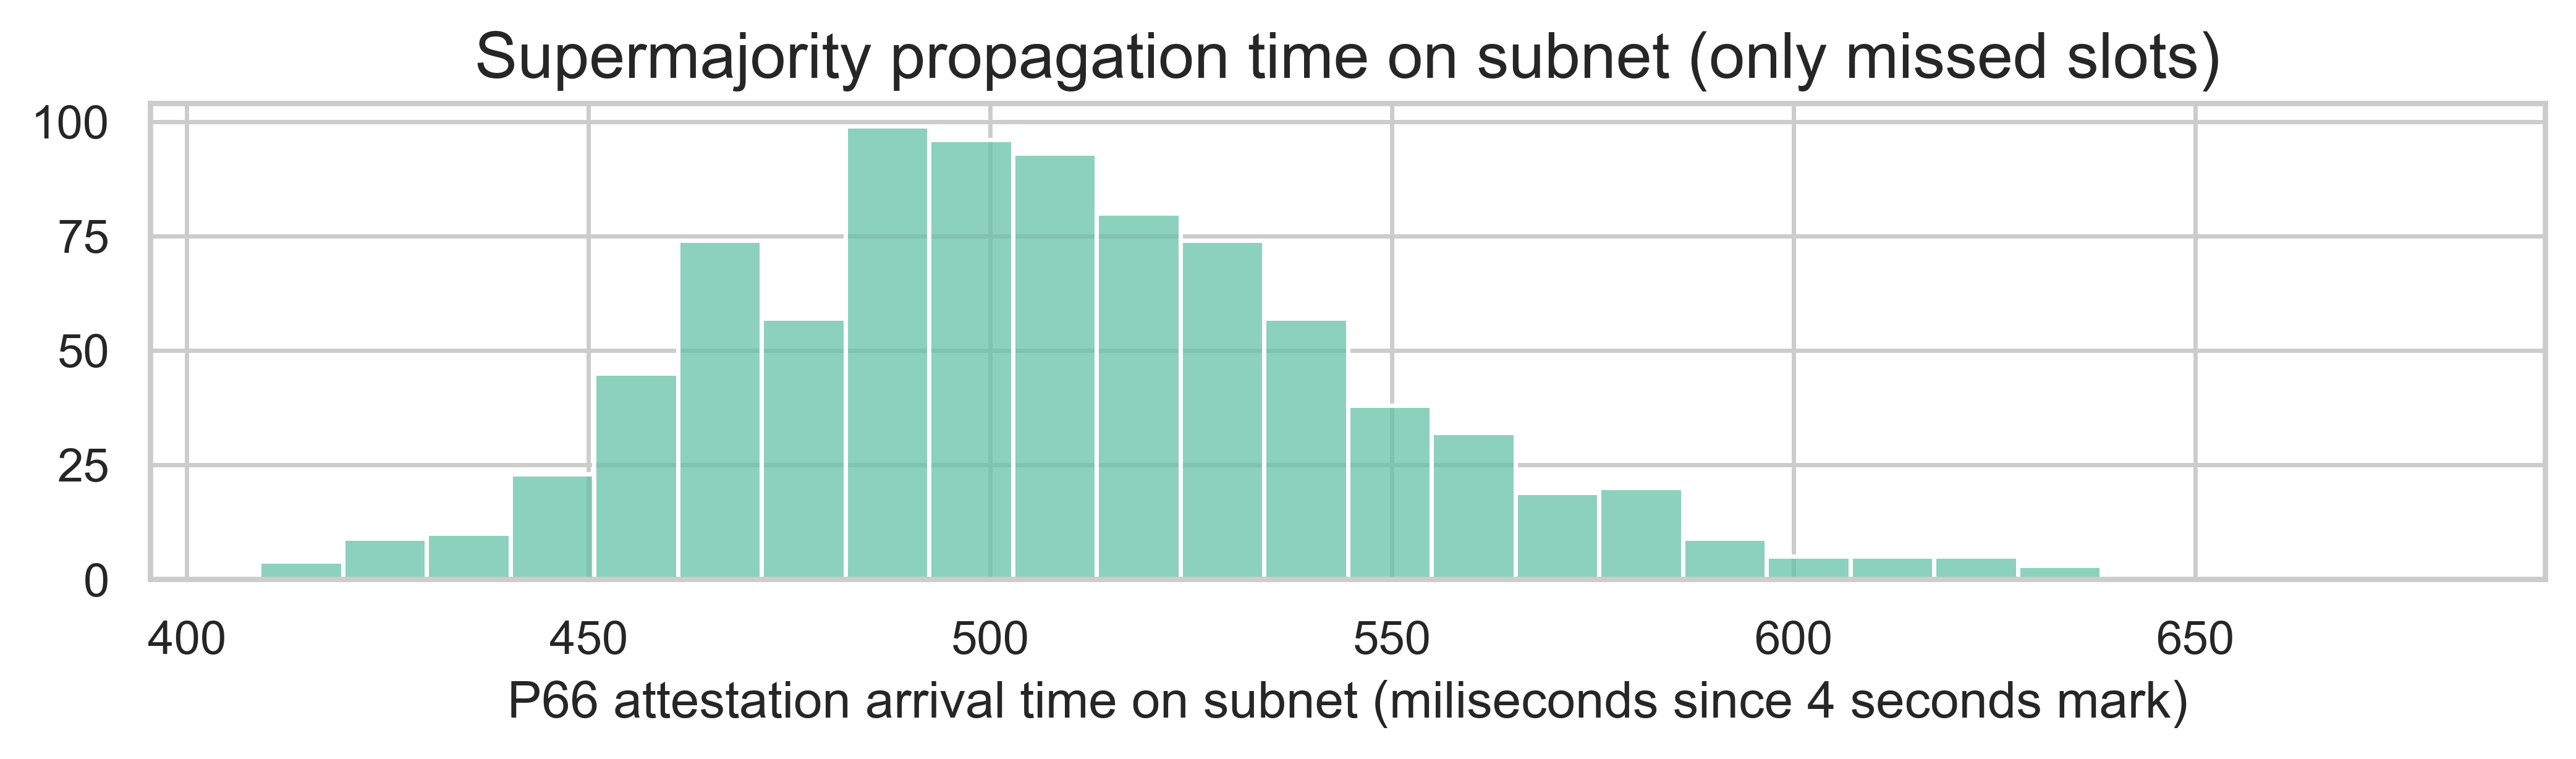

In [97]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.66], x="atts_prop_time_ms")
plt.title("Supermajority propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P66 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

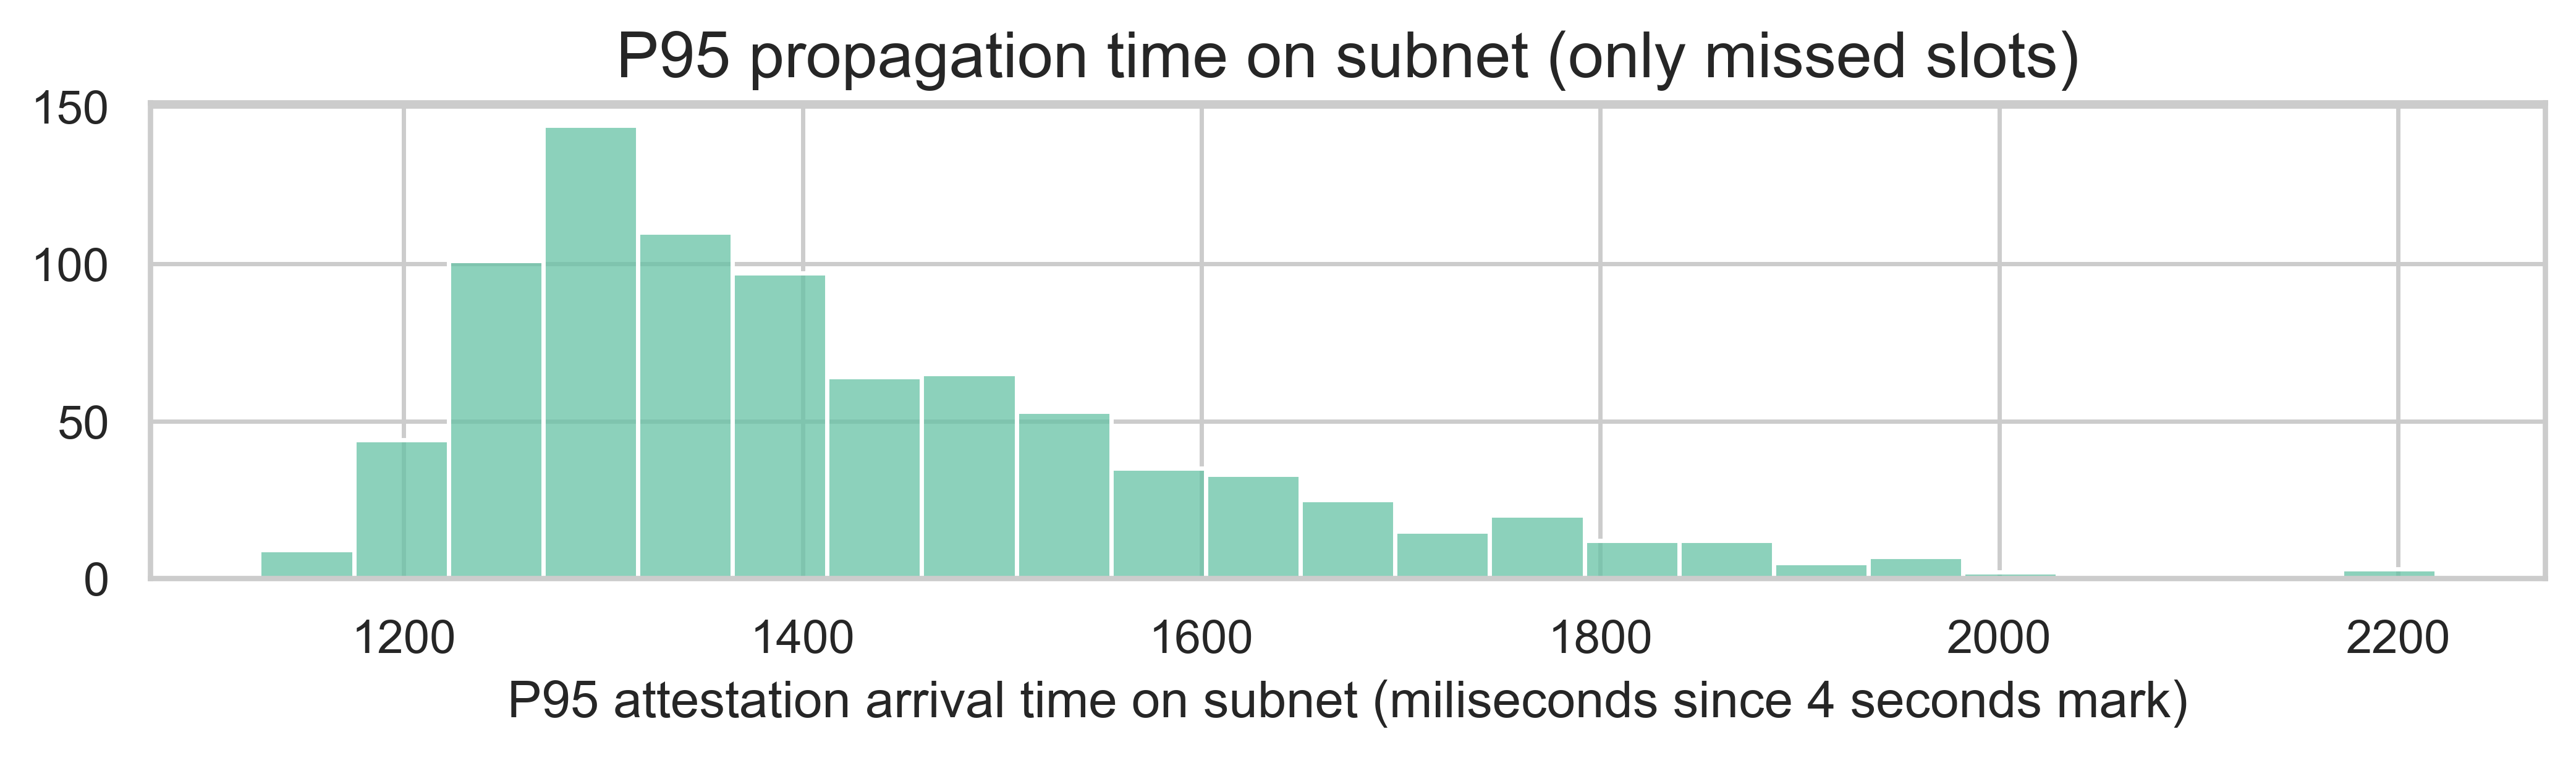

In [98]:
plt.figure(figsize=(10, 2))
sns.histplot(data=agg_df[agg_df["Percentile"]==0.95], x="atts_prop_time_ms")
plt.title("P95 propagation time on subnet (only missed slots)")
plt.ylabel("")
plt.xlabel("P95 attestation arrival time on subnet (miliseconds since 4 seconds mark)")
plt.show()

In [99]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].quantile(0.95)

Percentile
0.66     577.397
0.95    1787.900
Name: atts_prop_time_ms, dtype: float64

In [100]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].max()

Percentile
0.66     680.0
0.95    2219.1
Name: atts_prop_time_ms, dtype: float64

In [101]:
agg_df.groupby("Percentile")["atts_prop_time_ms"].mean()

Percentile
0.66     507.221282
0.95    1423.597552
Name: atts_prop_time_ms, dtype: float64

## 5. Example CDFs

    percentile  attes_time
0         0.00         1.0
1         0.05       187.0
2         0.10       244.0
3         0.15       290.0
4         0.20       331.0
5         0.25       372.0
6         0.30       414.0
7         0.35       453.0
8         0.40       493.0
9         0.45       533.0
10        0.50       575.0
11        0.55       622.0
12        0.60       674.0
13        0.65       728.0
14        0.70       792.0
15        0.75       874.0
16        0.80       987.0
17        0.85      1128.0
18        0.90      1290.0
19        0.95      1607.0
20        1.00      7994.0


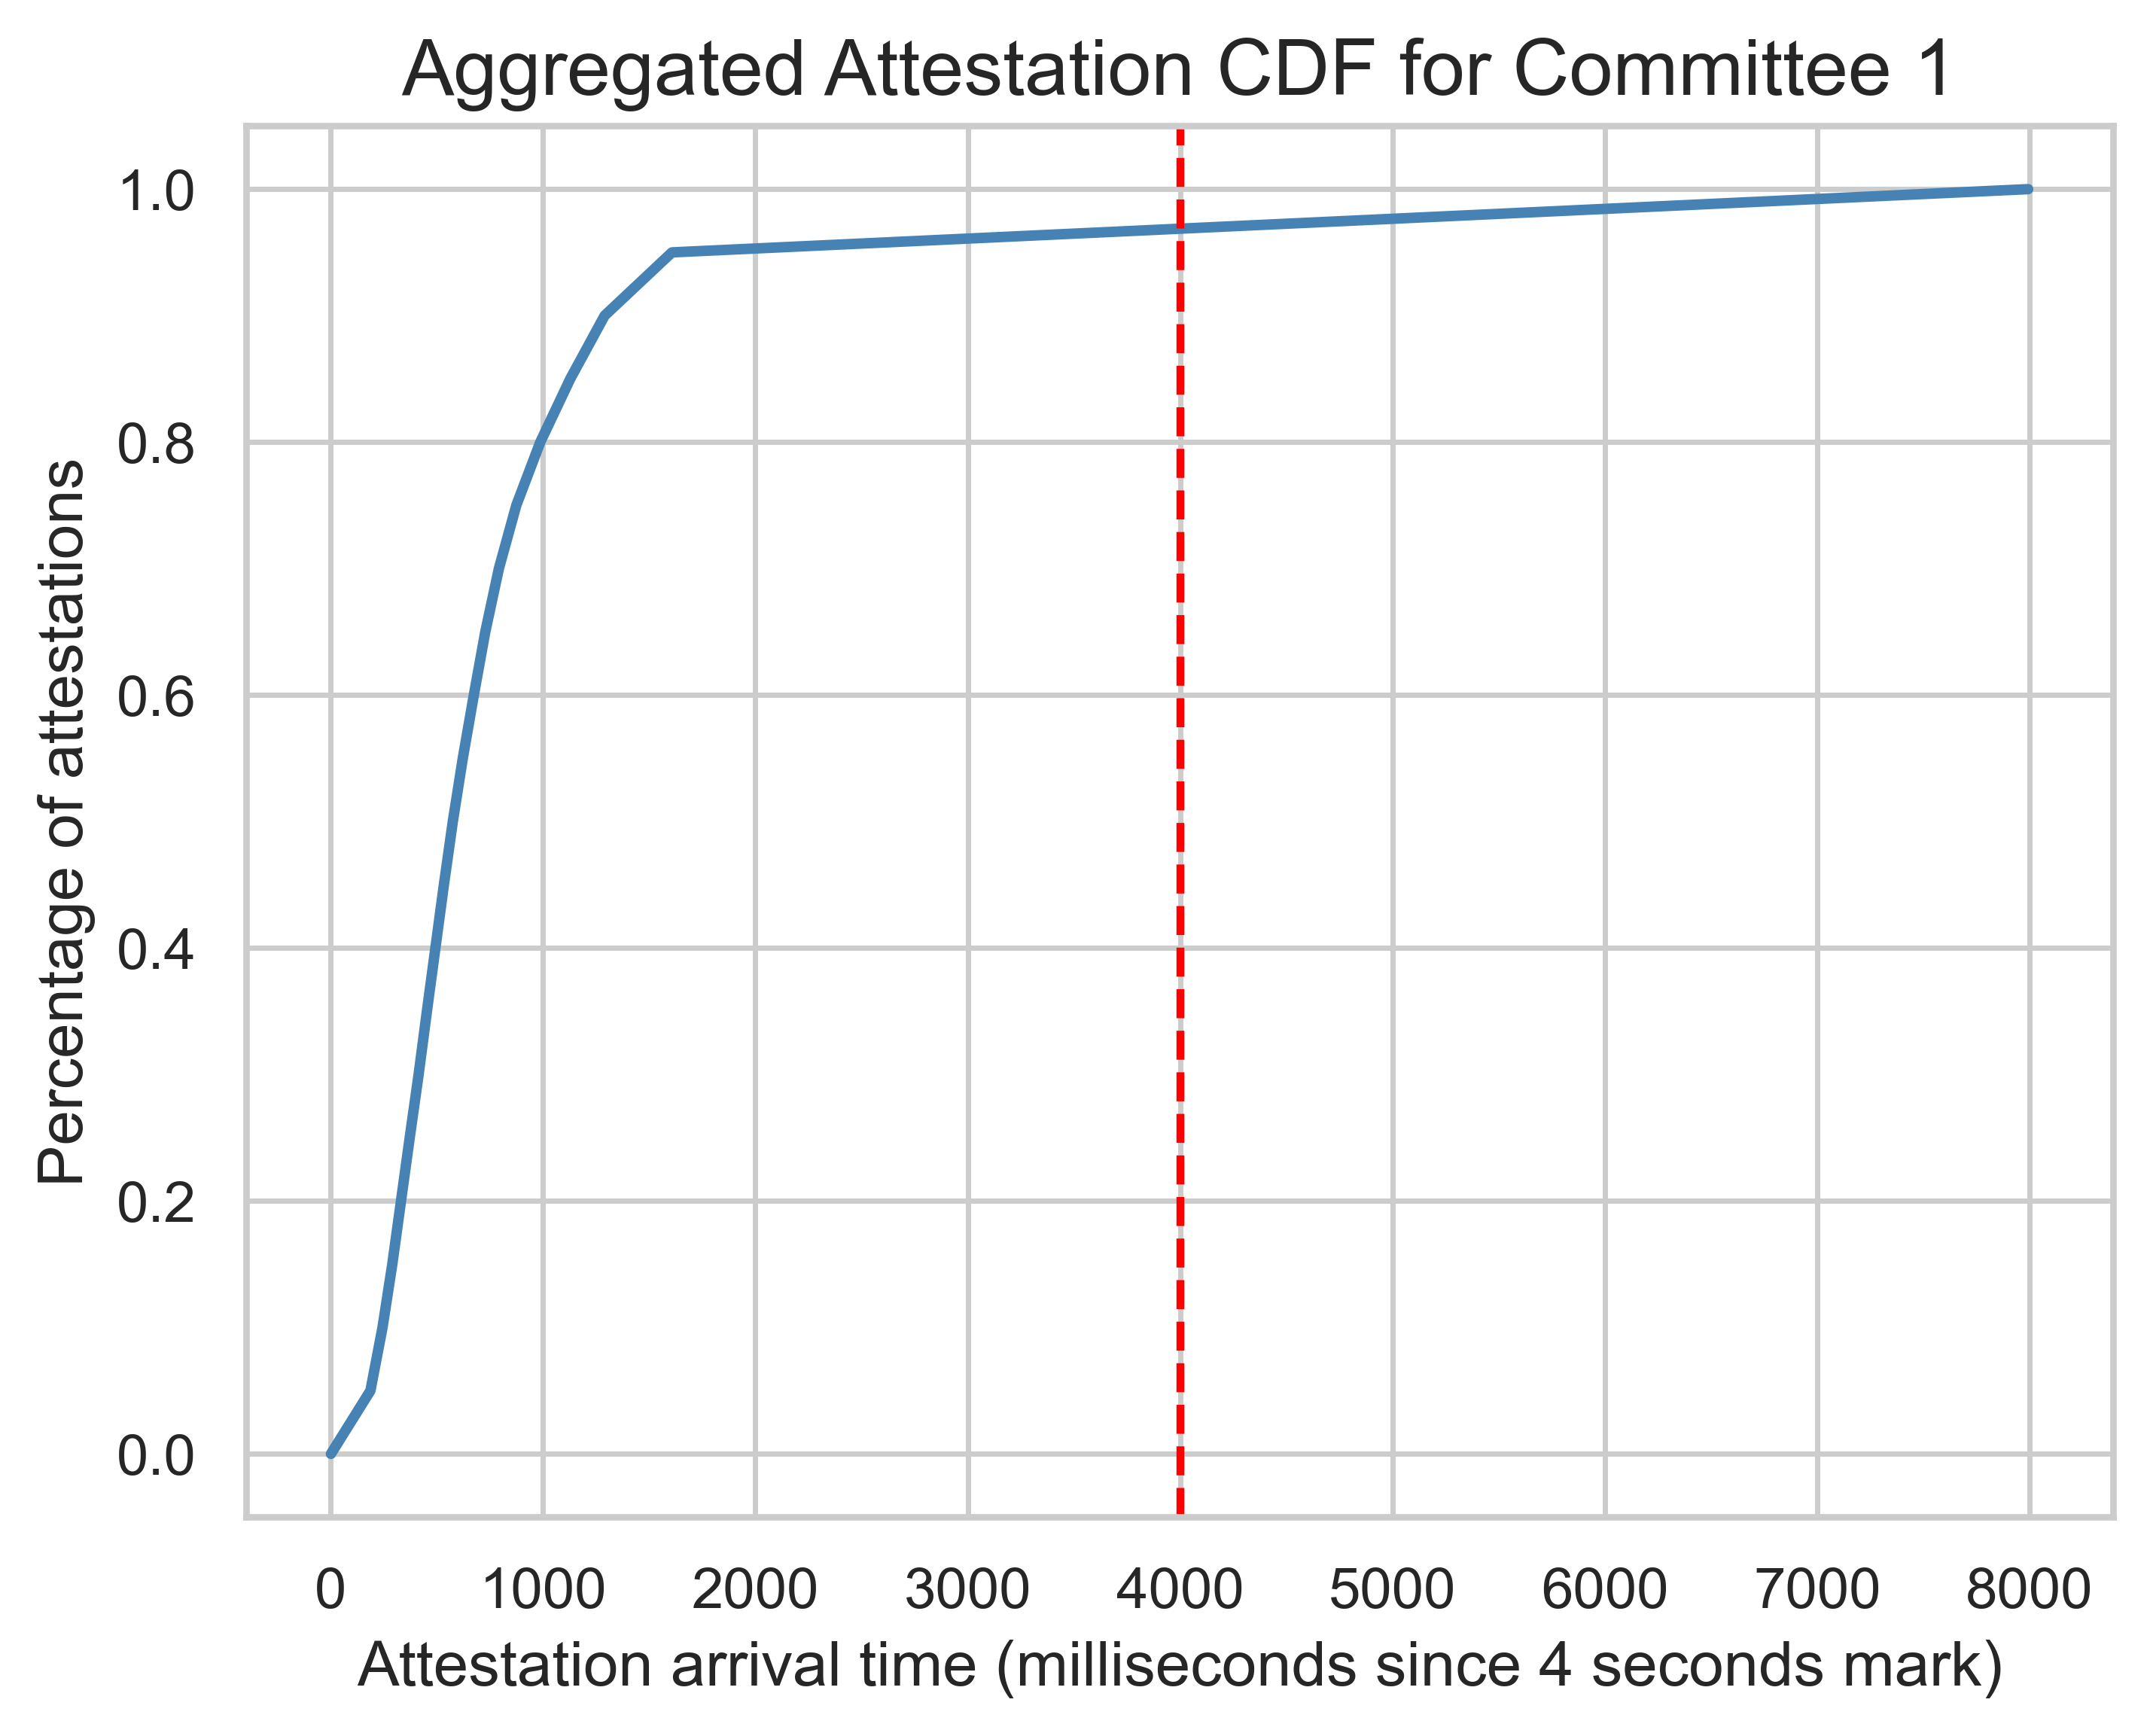

In [109]:
# Aggregate CDF across all nodes and slots for committee 1
temp_df = df[(df["atts_prop_time_ms"] > 0) & (atts_df["atts_subnet"] == "1")].copy()

# Calculate overall percentiles across all attestations
overall_percentiles = temp_df["atts_prop_time_ms"].quantile(np.arange(0, 1.05, 0.05)).reset_index()
overall_percentiles.columns = ["percentile", "attes_time"]

print(overall_percentiles)

# Create the aggregated CDF plot
ax = sns.lineplot(
    overall_percentiles,
    x="attes_time",
    y="percentile",
    color="steelblue",
    linewidth=2,
)
plt.axvline(x=4000, color="red", linestyle="dashed")
plt.title("Aggregated Attestation CDF for Committee 1")
plt.xlabel("Attestation arrival time (milliseconds since 4 seconds mark)")
plt.ylabel("Percentage of attestations")
plt.show()


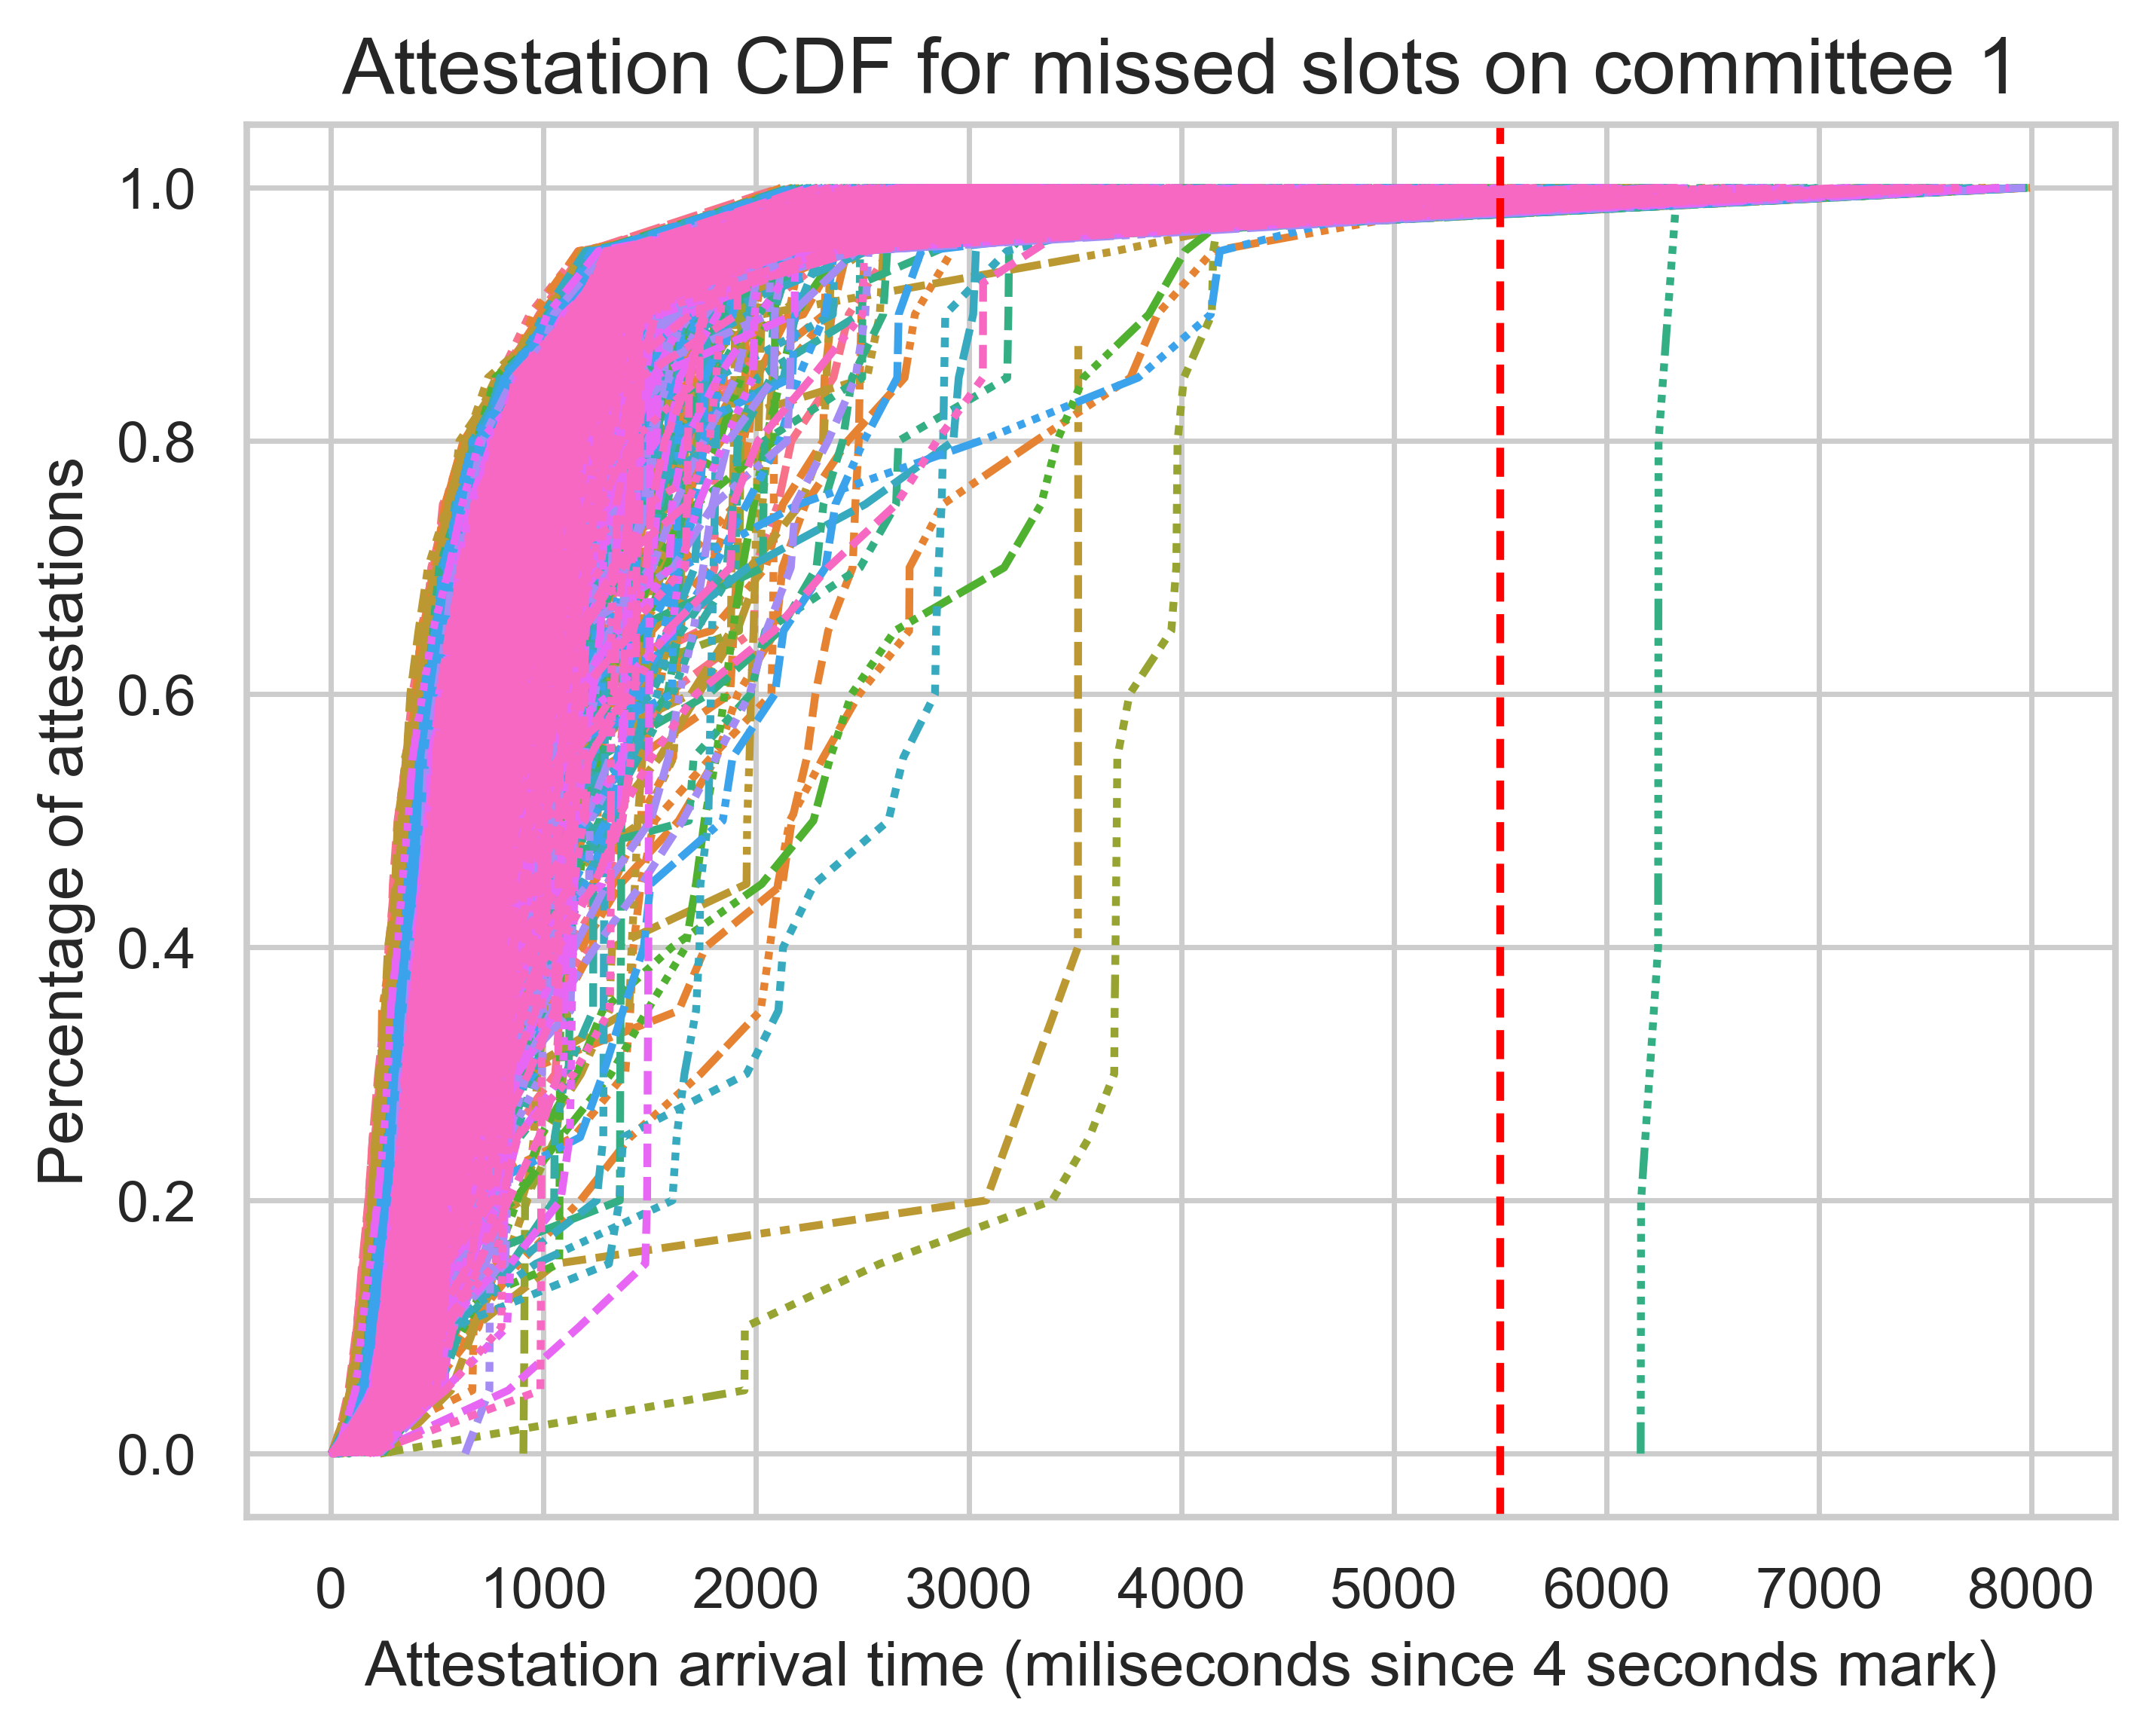

In [110]:
temp_df = df[(df["atts_prop_time_ms"] > 0) & (atts_df["atts_subnet"] == "1")].copy()
temp_df = (
    temp_df.groupby(["node_name", "slot"])["atts_prop_time_ms"]
    .quantile(np.arange(0, 1.05, 0.05))
    .reset_index()
)
temp_df.columns = ["node_name", "slot", "percentile", "attes_time"]

ax = sns.lineplot(
    temp_df,
    x="attes_time",
    y="percentile",
    hue="node_name",
    style="slot",
    errorbar=None,
    legend=False,
)
plt.axvline(x=5500, color="red", linestyle="dashed")
plt.title("Attestation CDF for missed slots on committee 1")
plt.xlabel("Attestation arrival time (miliseconds since 4 seconds mark)")
plt.ylabel("Percentage of attestations")
plt.show()

In [111]:
temp_df.groupby("percentile")["attes_time"].mean().head(25)

percentile
0.00      95.381481
0.05     220.627398
0.10     274.092047
0.15     316.572992
0.20     358.238830
0.25     403.096540
0.30     444.337193
0.35     482.460039
0.40     520.392437
0.45     556.197661
0.50     592.304971
0.55     631.724142
0.60     676.499532
0.65     722.056862
0.70     772.646784
0.75     834.675634
0.80     929.956140
0.85    1084.103986
0.90    1269.143158
0.95    1553.058499
1.00    3439.832943
Name: attes_time, dtype: float64